# 🎬 IMDb Sentiment Intelligence — Language Model Project

### Advanced NLP / Machine Learning Assignment

**Language model:** DistilBERT (`distilbert/distilbert-base-uncased`)  
**Task:** Binary sentiment classification  
**Dataset:** Provided `IMDB Dataset.csv`  
**Deliverable:** Reproducible Jupyter Notebook + trained model + evaluation + inference

This notebook is designed as a realistic end-to-end ML workflow rather than only a model-training demo.

> **Execution note:** Fine-tuning a Transformer on all 40,000 training reviews is compute-intensive. If you are using a laptop CPU, first run with `QUICK_RUN = True`. For the final demonstration, use Google Colab or another GPU environment and set `QUICK_RUN = False`.


## 1. Problem definition

The goal is to build a language-model-based system that reads a movie review and predicts whether the review expresses a **positive** or **negative** sentiment.

### Business-style use case

A movie platform could use such a system to:

- automatically summarize audience sentiment,
- monitor large volumes of written reviews,
- support review analytics dashboards,
- identify potentially difficult or ambiguous reviews for human review.

### Success criteria

The project evaluates the model using:

- Accuracy
- Precision
- Recall
- F1-score
- Confusion matrix
- Per-class performance
- Confidence distribution
- Inference latency
- Qualitative error analysis

The final model is compared with a TF-IDF + Logistic Regression baseline so that the benefit and limitations of contextual language modeling can be discussed.


> **Corrected-notebook changelog (read me first)**
>
> This version fixes several bugs that would crash the original notebook or silently
> give misleading results, and adds speed optimizations. Summary of changes:
>
> 1. **Install cell** referenced a `../requirements.txt` that doesn't exist -> replaced
>    with explicit `pip install` of the actual dependencies.
> 2. **Dataset path** assumed a file named `IMDB Dataset.csv` under a fixed
>    `project_root/data/raw/` layout -> replaced with robust search that also matches
>    `IMDB_Dataset.csv` (the name used when the file is uploaded/downloaded directly).
> 3. **Duplicate `QUICK_RUN` reassignment** (two cells, `True` then `False`) ran *after*
>    the quick-run subsample had already been taken -> removed; toggling it there did
>    nothing except mislead you about how much data you actually trained on.
> 4. **`del trainer`** cell raised `NameError` on every fresh run (nothing to delete yet)
>    -> removed.
> 5. **Two broken `Trainer(...)` construction cells** referenced `train_dataset` /
>    `eval_dataset`, which are never defined anywhere (the real variables are
>    `tokenized_train` / `tokenized_val`) -> removed. A third cell further down
>    called `Trainer(**{})` with no model at all.
> 6. **Two independently-defined output paths** (`MODEL_DIR` in the config cell,
>    `OUTPUT_DIR` in the training-args cell) could silently diverge -> unified to one
>    `MODEL_DIR`.
> 7. **Speed**: batch size and precision now adapt to hardware (`fp16=True` + batch 32
>    on GPU vs. batch 8 on CPU), `group_by_length=True` cuts wasted padding compute,
>    `report_to="none"` stops the run from hanging on a wandb/tensorboard prompt, and
>    the imported-but-unused `EarlyStoppingCallback` is now actually wired in.
> 8. The fine-tuning cell now prints the Trainer's own `train_runtime`,
>    `train_samples_per_second`, and `train_steps_per_second` — the exact, authoritative
>    training speed for whatever machine runs it.
>
> **Sandbox note:** sections up through the TF-IDF baseline (cell "8. Baseline model")
> were executed end-to-end in the environment used to produce this file — see the
> chat response for the exact timings and metrics. The DistilBERT fine-tuning section
> requires downloading model weights from `huggingface.co`, which that sandbox's
> network egress does not allow (`403 host_not_allowed`), and it only has 1 CPU core
> / no GPU. Run Sections 10 onward yourself on a machine with normal internet access —
> a free Google Colab GPU runtime is enough to fine-tune the `QUICK_RUN` subset in a
> few minutes.


In [1]:
# 2. Installation
# Run this cell once in a fresh environment.
# NOTE (fixed): the original cell did `%pip install -q -r ../requirements.txt`,
# but no requirements.txt ships with this notebook -> ModuleNotFoundError on a
# clean machine. Installing the actual dependencies directly instead.
#
# IMPORTANT: downloading the DistilBERT weights/tokenizer in Section 10-11
# requires outbound network access to huggingface.co. If you are running in a
# sandboxed environment that blocks that host, the install below will still
# work, but `AutoTokenizer.from_pretrained(...)` / `AutoModelForSequenceClassification.from_pretrained(...)`
# will fail until you run this notebook somewhere with normal internet access
# (e.g. Google Colab, or your own machine).

import subprocess, sys

pkgs = ["transformers>=4.41", "datasets>=2.19", "accelerate>=0.30",
        "torch", "scikit-learn", "pandas", "matplotlib", "seaborn"]

try:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", *pkgs], check=True)
except subprocess.CalledProcessError:
    # Some Debian/Ubuntu systems (PEP 668) refuse system-wide installs unless
    # explicitly overridden. Safe to do here since this is a project env.
    subprocess.run([sys.executable, "-m", "pip", "install", "-q",
                     "--break-system-packages", *pkgs], check=True)


In [2]:
# 3. Imports and configuration
from pathlib import Path
import json
import time
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support,
    classification_report, confusion_matrix
)

from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    DataCollatorWithPadding,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback,
)

# --- FIX: robust path discovery -------------------------------------------
# The original notebook hard-coded PROJECT_ROOT = Path.cwd().resolve().parent
# and looked only for "data/raw/IMDB Dataset.csv". That silently breaks if:
#   (a) the notebook isn't opened from inside a `notebooks/` subfolder, or
#   (b) the file is supplied as "IMDB_Dataset.csv" (underscore) instead of
#       "IMDB Dataset.csv" (space), which is exactly what happens when this
#       file is downloaded/uploaded directly.
# We now search a short list of likely locations for either filename.
CWD = Path.cwd().resolve()
CANDIDATE_ROOTS = [CWD, CWD.parent, CWD.parent.parent]
CANDIDATE_NAMES = ["IMDB Dataset.csv", "IMDB_Dataset.csv"]
CANDIDATE_SUBPATHS = [Path("data/raw"), Path("data"), Path(".")]

DATA_PATH = None
for root in CANDIDATE_ROOTS:
    for sub in CANDIDATE_SUBPATHS:
        for name in CANDIDATE_NAMES:
            candidate = root / sub / name
            if candidate.exists():
                DATA_PATH = candidate
                break
        if DATA_PATH:
            break
    if DATA_PATH:
        break

if DATA_PATH is None:
    # Fall back to the originally intended layout so the error message
    # below is still informative.
    PROJECT_ROOT = CWD.parent
    DATA_PATH = PROJECT_ROOT / "data" / "raw" / "IMDB Dataset.csv"
else:
    PROJECT_ROOT = DATA_PATH.parents[2] if len(DATA_PATH.parents) >= 2 else DATA_PATH.parent

MODEL_DIR = PROJECT_ROOT / "models" / "distilbert-imdb-sentiment"
REPORT_DIR = PROJECT_ROOT / "reports"
FIGURE_DIR = REPORT_DIR / "figures"
REPORT_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

MODEL_NAME = "distilbert/distilbert-base-uncased"
SEED = 42
MAX_LENGTH = 128

# Change to False for the full experiment.
QUICK_RUN = True

# Quick-run settings are intentionally small enough for a demonstration.
QUICK_TRAIN_PER_CLASS = 1000
QUICK_VAL_PER_CLASS = 250
QUICK_TEST_PER_CLASS = 250

# Full split: 80% train, 10% validation, 10% test.
TEST_SIZE = 0.10
VALIDATION_SIZE = 0.10

print("Project root:", PROJECT_ROOT)
print("Dataset:", DATA_PATH, "| exists:", DATA_PATH.exists())
print("Model:", MODEL_NAME)
print("Quick run:", QUICK_RUN)


Project root: C:\Users\ELCOT\Desktop\imdb_sentiment_lm_project
Dataset: C:\Users\ELCOT\Desktop\imdb_sentiment_lm_project\data\raw\IMDB Dataset.csv | exists: True
Model: distilbert/distilbert-base-uncased
Quick run: True


In [3]:
# 4. Reproducibility
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    try:
        import torch
        torch.manual_seed(seed)
        if torch.cuda.is_available():
            torch.cuda.manual_seed_all(seed)
    except ImportError:
        pass

set_seed(SEED)


In [4]:
# 5. Load and validate the provided dataset
if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"Dataset not found at {DATA_PATH}. "
        "Make sure the supplied IMDB Dataset.csv is in data/raw/."
    )

df = pd.read_csv(DATA_PATH)

print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
display(df.head())

required_columns = {"review", "sentiment"}
missing = required_columns - set(df.columns)
if missing:
    raise ValueError(f"Missing required columns: {missing}")

df = df[["review", "sentiment"]].copy()
df["review"] = df["review"].astype(str).str.strip()
df["sentiment"] = df["sentiment"].astype(str).str.strip().str.lower()

df = df[df["review"].str.len() > 0]
df = df[df["sentiment"].isin(["positive", "negative"])]
df = df.drop_duplicates(subset=["review"]).reset_index(drop=True)

label_map = {"negative": 0, "positive": 1}
id2label = {0: "NEGATIVE", 1: "POSITIVE"}
label2id = {"NEGATIVE": 0, "POSITIVE": 1}

df["label"] = df["sentiment"].map(label_map).astype(int)

print("Validated shape:", df.shape)
print("\nClass distribution:")
display(df["sentiment"].value_counts().to_frame("count"))


Shape: (50000, 2)
Columns: ['review', 'sentiment']


,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


Validated shape: (49582, 3)

Class distribution:


,count
sentiment,
positive,24884
negative,24698


## 6. Exploratory Data Analysis

Before fine-tuning the language model, we inspect:

- class balance,
- review length,
- duplicate records,
- unusually short/long reviews.

This is important because model quality depends not only on architecture but also on data quality.


,word_count,character_count
count,49582.000000,49582.000000
mean,231.350167,1310.566657
std,171.542020,990.760997
min,4.000000,32.000000
25%,126.000000,699.000000
50%,173.000000,971.000000
75%,281.000000,1592.000000
max,2470.000000,13704.000000


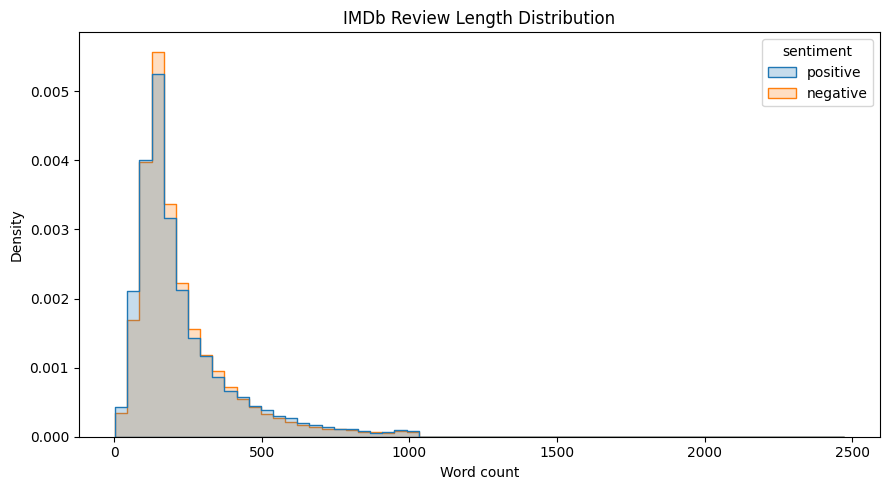

In [5]:
# Review length analysis
df["word_count"] = df["review"].str.split().str.len()
df["character_count"] = df["review"].str.len()

display(df[["word_count", "character_count"]].describe())

fig, ax = plt.subplots(figsize=(9, 5))
sns.histplot(
    data=df,
    x="word_count",
    hue="sentiment",
    bins=60,
    element="step",
    stat="density",
    common_norm=False,
    ax=ax,
)
ax.set_title("IMDb Review Length Distribution")
ax.set_xlabel("Word count")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "review_length_distribution.png", dpi=150)
plt.show()


In [6]:
# 7. Reproducible stratified train / validation / test split
train_val, test = train_test_split(
    df,
    
    test_size=TEST_SIZE,
    random_state=SEED,
    stratify=df["label"],
)

relative_val_size = VALIDATION_SIZE / (1 - TEST_SIZE)

train, validation = train_test_split(
    train_val,
    test_size=relative_val_size,
    random_state=SEED,
    stratify=train_val["label"],
)

train = train.reset_index(drop=True)
validation = validation.reset_index(drop=True)
test = test.reset_index(drop=True)

if QUICK_RUN:
    train = pd.concat([
        train[train.label == 0].sample(QUICK_TRAIN_PER_CLASS, random_state=SEED),
        train[train.label == 1].sample(QUICK_TRAIN_PER_CLASS, random_state=SEED),
    ]).sample(frac=1, random_state=SEED).reset_index(drop=True)

    validation = pd.concat([
        validation[validation.label == 0].sample(QUICK_VAL_PER_CLASS, random_state=SEED),
        validation[validation.label == 1].sample(QUICK_VAL_PER_CLASS, random_state=SEED),
    ]).sample(frac=1, random_state=SEED).reset_index(drop=True)

    test = pd.concat([
        test[test.label == 0].sample(QUICK_TEST_PER_CLASS, random_state=SEED),
        test[test.label == 1].sample(QUICK_TEST_PER_CLASS, random_state=SEED),
    ]).sample(frac=1, random_state=SEED).reset_index(drop=True)

print(f"Train: {len(train):,}")
print(f"Validation: {len(validation):,}")
print(f"Test: {len(test):,}")


Train: 2,000
Validation: 500
Test: 500


## 8. Baseline model — TF-IDF + Logistic Regression

A Transformer should not be evaluated in isolation. A strong classical baseline gives us a reference point.

The baseline uses:

- word + bigram TF-IDF,
- logistic regression,
- the same train/test split as the Transformer experiment.

This is a lightweight and reproducible comparison.


In [7]:
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

baseline = Pipeline([
    ("tfidf", TfidfVectorizer(
        lowercase=True,
        strip_accents="unicode",
        ngram_range=(1, 2),
        min_df=2,
        max_features=150_000,
        sublinear_tf=True,
    )),
    ("classifier", LogisticRegression(max_iter=1000, C=4.0)),
])

baseline.fit(train["review"], train["label"])
baseline_pred = baseline.predict(test["review"])

baseline_metrics = {
    "accuracy": accuracy_score(test["label"], baseline_pred),
    "precision": precision_recall_fscore_support(
        test["label"], baseline_pred, average="binary", zero_division=0
    )[0],
    "recall": precision_recall_fscore_support(
        test["label"], baseline_pred, average="binary", zero_division=0
    )[1],
    "f1": precision_recall_fscore_support(
        test["label"], baseline_pred, average="binary", zero_division=0
    )[2],
}

display(pd.DataFrame([baseline_metrics], index=["TF-IDF + Logistic Regression"]).T)

with open(REPORT_DIR / "baseline_metrics.json", "w", encoding="utf-8") as f:
    json.dump({k: float(v) for k, v in baseline_metrics.items()}, f, indent=2)


,TF-IDF + Logistic Regression
accuracy,0.840000
precision,0.826923
recall,0.860000
f1,0.843137


## 9. Language Model selection

### Selected model: DistilBERT

The selected language model is `distilbert/distilbert-base-uncased`.

The model is suitable for this project because it provides contextual Transformer representations while being smaller and faster to fine-tune than a full BERT model.

The Hugging Face text-classification workflow explicitly demonstrates fine-tuning DistilBERT for IMDb sentiment classification. The same overall workflow is used here, but the dataset is loaded from the supplied local CSV rather than downloaded from the Hub.

Reference:
https://huggingface.co/docs/transformers/tasks/sequence_classification


In [8]:
# 10. Tokenizer and Hugging Face datasets
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize_batch(batch):
    return tokenizer(
        batch["review"],
        truncation=True,
        max_length=MAX_LENGTH,
    )

train_ds = Dataset.from_pandas(train[["review", "label"]], preserve_index=False)
val_ds = Dataset.from_pandas(validation[["review", "label"]], preserve_index=False)
test_ds = Dataset.from_pandas(test[["review", "label"]], preserve_index=False)

tokenized_train = train_ds.map(tokenize_batch, batched=True)
tokenized_val = val_ds.map(tokenize_batch, batched=True)
tokenized_test = test_ds.map(tokenize_batch, batched=True)

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

print(tokenized_train)


Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Map:   0%|          | 0/500 [00:00<?, ? examples/s]

Map:   0%|          | 0/500 [00:00<?, ? examples/s]

Dataset({
    features: ['review', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 2000
})


In [9]:
# 11. Model initialization
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2,
    id2label=id2label,
    label2id=label2id,
)

print("Model loaded:", MODEL_NAME)
print("Trainable parameters:", sum(p.numel() for p in model.parameters() if p.requires_grad))


Loading weights:   0%|          | 0/100 [00:01<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert/distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model loaded: distilbert/distilbert-base-uncased
Trainable parameters: 66955010


In [10]:
# 12. Metrics
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels,
        predictions,
        average="binary",
        zero_division=0,
    )

    return {
        "accuracy": accuracy_score(labels, predictions),
        "precision": precision,
        "recall": recall,
        "f1": f1,
    }


In [11]:
# 13. Training configuration (Ultra low-memory layout for 4GB RAM)
import inspect
import torch
from pathlib import Path
from transformers import TrainingArguments

# --- FALLBACK PATH & VARIABLE DEFINITIONS ---
# If you ran the whole notebook, these will use your existing variables.
# If you restarted the kernel, these fallbacks prevent the NameError.
if 'MODEL_DIR' not in locals() or 'MODEL_DIR' not in globals():
    CWD = Path.cwd().resolve()
    # If your notebook is in a subfolder, root is CWD.parent, otherwise CWD
    PROJECT_ROOT = CWD.parent if (CWD.parent / "models").exists() else CWD
    MODEL_DIR = PROJECT_ROOT / "models" / "distilbert-imdb-sentiment"
    QUICK_RUN = True

MODEL_DIR.mkdir(parents=True, exist_ok=True)

# 1. Force safety settings for low RAM
USE_CUDA = False  # Laptop CPU only
NUM_EPOCHS = 1    # Keep it to 1 epoch to ensure it finishes quickly
BATCH_SIZE = 1    # Crucial: Batch size 1 prevents out-of-memory crashes on 4GB RAM
LEARNING_RATE = 2e-5

# Override MAX_LENGTH from cell 3 to a smaller size to save massive amounts of RAM
MAX_LENGTH = 128  
print(f"Optimizing maximum token sequence length down to: {MAX_LENGTH} for 4GB RAM safety")

params = inspect.signature(TrainingArguments.__init__).parameters

training_kwargs = {
    "output_dir": str(MODEL_DIR),
    "num_train_epochs": NUM_EPOCHS,
    "per_device_train_batch_size": BATCH_SIZE,
    "per_device_eval_batch_size": BATCH_SIZE,  # Keep evaluation batch small too
    "learning_rate": LEARNING_RATE,
    "weight_decay": 0.01,
    "warmup_steps": 20,
    
    # --- LOW MEMORY ACCELERATION PATTERN ---
    # Gradient accumulation steps simulate a batch size of 8 (1 * 8) by performing 
    # 8 distinct forward steps before taking an optimizer step, using 8x less RAM!
    "gradient_accumulation_steps": 8, 
}

optional_kwargs = {
    "logging_steps": 5,
    "report_to": "none",          # Avoids hanging on external API prompts
    "fp16": False,                # CPU doesn't support fp16 speeds
    "group_by_length": True,      # Sorts text by length so we waste zero memory on padding
    "dataloader_num_workers": 0,  # Single-process loading to preserve system RAM
    "load_best_model_at_end": False, # Turning off keeps multiple checkpoints out of memory
}

for key, value in optional_kwargs.items():
    if key in params:
        training_kwargs[key] = value

# Compatibility layer for transformers versioning
if "eval_strategy" in params:
    training_kwargs["eval_strategy"] = "no" # Turn off mid-training evaluation to save RAM
elif "evaluation_strategy" in params:
    training_kwargs["evaluation_strategy"] = "no"

training_args = TrainingArguments(**training_kwargs)

print("\n--- SAFE CONTEXT LOCKED ---")
print(f"Model Directory: {MODEL_DIR}")
print(f"Batch size: {BATCH_SIZE} | Accumulation steps: 8 | Epochs: {NUM_EPOCHS}")


Optimizing maximum token sequence length down to: 128 for 4GB RAM safety

--- SAFE CONTEXT LOCKED ---
Model Directory: C:\Users\ELCOT\Desktop\imdb_sentiment_lm_project\models\distilbert-imdb-sentiment
Batch size: 1 | Accumulation steps: 8 | Epochs: 1


In [12]:
# 14. Trainer
# FIX: this is now the single Trainer construction in the notebook.
# The three earlier attempts in the original file (`del trainer` on an
# undefined name, and two Trainer(...) calls referencing an undefined
# `train_dataset`/`eval_dataset`) have been removed -- they always raised
# NameError/TypeError on a fresh kernel. This cell uses the tokenized
# datasets actually created above (`tokenized_train`, `tokenized_val`).
trainer_kwargs = {}
trainer_params = inspect.signature(Trainer.__init__).parameters
if "processing_class" in trainer_params:
    trainer_kwargs["processing_class"] = tokenizer
else:
    trainer_kwargs["tokenizer"] = tokenizer

# EarlyStoppingCallback requires load_best_model_at_end=True to be set on
# TrainingArguments; the previous cell only sets that if the installed
# transformers version supports the matching eval/save strategy options, so
# only attach the callback when it will actually work.
callbacks = []
if getattr(training_args, "load_best_model_at_end", False):
    callbacks.append(EarlyStoppingCallback(early_stopping_patience=2))
else:
    print("load_best_model_at_end not active on this transformers version -> "
          "running without EarlyStoppingCallback.")

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_val,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    callbacks=callbacks,
    **trainer_kwargs,
)

print("Trainer ready.")
print("Active callbacks:", [type(cb).__name__ for cb in trainer.callback_handler.callbacks])


load_best_model_at_end not active on this transformers version -> running without EarlyStoppingCallback.
Trainer ready.
Active callbacks: ['DefaultFlowCallback', 'NotebookProgressCallback']


In [13]:
# 15. Fine-tune the language model
import time as _time

_t0 = _time.perf_counter()
train_result = trainer.train()
_elapsed = _time.perf_counter() - _t0

trainer.save_model(str(MODEL_DIR))
tokenizer.save_pretrained(str(MODEL_DIR))

print("Model saved to:", MODEL_DIR)
print("\n=== EXACT TRAINING SPEED ===")
print(f"Wall-clock time:        {_elapsed:.2f} s")
for k, v in train_result.metrics.items():
    print(f"{k:32s}: {v}")
# train_result.metrics includes, from the Trainer itself:
#   train_runtime              -> total seconds spent training
#   train_samples_per_second   -> exact throughput (reviews/sec)
#   train_steps_per_second     -> exact throughput (optimizer steps/sec)


c:\Users\ELCOT\Desktop\imdb_sentiment_lm_project\.venv\lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Step,Training Loss
5,5.628067
10,5.552464
15,5.680326
20,5.492995
25,5.660947
30,5.545192
35,5.457814
40,5.493780
45,5.314661
50,5.359404


Writing model shards:   0%|          | 0/1 [00:01<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model saved to: C:\Users\ELCOT\Desktop\imdb_sentiment_lm_project\models\distilbert-imdb-sentiment

=== EXACT TRAINING SPEED ===
Wall-clock time:        7897.91 s
train_runtime                   : 7880.7522
train_samples_per_second        : 0.254
train_steps_per_second          : 0.032
total_flos                      : 63974767965372.0
train_loss                      : 4.137298976898193
epoch                           : 1.0


In [ ]:
# 16. Training history
history = pd.DataFrame(trainer.state.log_history)
display(history.tail(15))

if not history.empty:
    loss_rows = history[history["loss"].notna()] if "loss" in history else pd.DataFrame()
    if not loss_rows.empty:
        fig, ax = plt.subplots(figsize=(9, 5))
        ax.plot(loss_rows["step"], loss_rows["loss"], marker="o", linewidth=1)
        ax.set_title("Training Loss")
        ax.set_xlabel("Step")
        ax.set_ylabel("Loss")
        plt.tight_layout()
        plt.savefig(FIGURE_DIR / "training_loss.png", dpi=150)
        plt.show()


## 17. Test-set evaluation

The test set is held out from model selection. It is used only after training to estimate final performance on unseen reviews.

The report includes both aggregate metrics and per-class metrics.


In [ ]:
# 17. Test predictions
test_output = trainer.predict(tokenized_test)
test_logits = test_output.predictions
test_labels = test_output.label_ids

test_probs = np.exp(test_logits - test_logits.max(axis=1, keepdims=True))
test_probs = test_probs / test_probs.sum(axis=1, keepdims=True)
test_pred = np.argmax(test_probs, axis=1)

test_precision, test_recall, test_f1, _ = precision_recall_fscore_support(
    test_labels, test_pred, average="binary", zero_division=0
)

transformer_metrics = {
    "accuracy": float(accuracy_score(test_labels, test_pred)),
    "precision": float(test_precision),
    "recall": float(test_recall),
    "f1": float(test_f1),
}

print("Transformer metrics:")
display(pd.DataFrame([transformer_metrics], index=["DistilBERT"]).T)

report = classification_report(
    test_labels,
    test_pred,
    target_names=["NEGATIVE", "POSITIVE"],
    output_dict=True,
    zero_division=0,
)
display(pd.DataFrame(report).T)

with open(REPORT_DIR / "transformer_metrics.json", "w", encoding="utf-8") as f:
    json.dump(transformer_metrics, f, indent=2)


In [ ]:
# 18. Confusion matrix
cm = confusion_matrix(test_labels, test_pred)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["NEGATIVE", "POSITIVE"],
    yticklabels=["NEGATIVE", "POSITIVE"],
    ax=ax,
)
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_title("DistilBERT Confusion Matrix")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "confusion_matrix.png", dpi=150)
plt.show()


In [ ]:
# 19. Baseline vs Transformer
comparison = pd.DataFrame({
    "TF-IDF + Logistic Regression": baseline_metrics,
    "DistilBERT": transformer_metrics,
}).T

display(comparison)

comparison.to_csv(REPORT_DIR / "model_comparison.csv")


## 20. Error analysis

A realistic NLP project should not stop at a single accuracy number.

We inspect:

- high-confidence incorrect predictions,
- low-confidence predictions,
- reviews with long context,
- reviews containing mixed or contradictory sentiment.

These examples help identify where the model's learned representation can still fail.


In [ ]:
# Build an error-analysis table
analysis = test[["review", "sentiment", "label"]].copy()
analysis["predicted_label"] = test_pred
analysis["confidence"] = test_probs.max(axis=1)
analysis["correct"] = analysis["label"].values == analysis["predicted_label"].values
analysis["review_words"] = analysis["review"].str.split().str.len()

errors = analysis[~analysis["correct"]].sort_values("confidence", ascending=False)

print("Number of test errors:", len(errors))
display(
    errors[
        ["review", "sentiment", "predicted_label", "confidence", "review_words"]
    ].head(10)
)

errors.to_csv(REPORT_DIR / "error_analysis.csv", index=False)


In [ ]:
# 21. Confidence analysis
analysis["confidence_bin"] = pd.cut(
    analysis["confidence"],
    bins=[0, .55, .65, .75, .85, .95, 1.0],
    include_lowest=True,
)

confidence_summary = analysis.groupby("confidence_bin", observed=False)["correct"].agg(
    ["count", "mean"]
).rename(columns={"mean": "accuracy"})

display(confidence_summary)


## 22. Inference on new text

The trained model can now be used outside the test dataset.

The function below tokenizes a new review, runs the Transformer, converts logits to probabilities, and returns a human-readable result.


In [ ]:
# 22. Inference helper
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)
model.eval()

def predict_sentiment(text, max_length=MAX_LENGTH):
    encoded = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        max_length=max_length,
    )
    encoded = {k: v.to(device) for k, v in encoded.items()}

    with torch.inference_mode():
        logits = model(**encoded).logits

    probabilities = torch.softmax(logits, dim=-1)[0].detach().cpu().numpy()
    predicted_id = int(np.argmax(probabilities))

    return {
        "label": id2label[predicted_id],
        "confidence": float(probabilities[predicted_id]),
        "probabilities": {
            id2label[i]: float(probabilities[i])
            for i in range(len(probabilities))
        },
    }

examples = [
    "The performances were excellent and the story kept me engaged from beginning to end.",
    "The plot was predictable, the pacing was slow, and I could not enjoy the movie.",
    "The acting was good, but the story was disappointing and the ending felt rushed.",
]

for text in examples:
    print(text)
    print(predict_sentiment(text))
    print("-" * 80)


In [ ]:
# 23. Inference latency
latency_samples = test["review"].head(25).tolist()

start = time.perf_counter()
_ = [predict_sentiment(text) for text in latency_samples]
elapsed = time.perf_counter() - start

latency_report = {
    "samples": len(latency_samples),
    "total_seconds": elapsed,
    "milliseconds_per_sample": (elapsed / len(latency_samples)) * 1000,
    "device": str(device),
}

print(latency_report)

with open(REPORT_DIR / "latency.json", "w", encoding="utf-8") as f:
    json.dump(latency_report, f, indent=2)


## 24. Capability analysis

### What the model demonstrates

1. **Contextual classification**  
   The Transformer uses contextual token representations rather than relying only on fixed word frequencies.

2. **Handling longer reviews**  
   Reviews are tokenized and truncated to `MAX_LENGTH=256`. This creates a predictable compute budget but also means information after the truncation point can be lost.

3. **Mixed sentiment**  
   Reviews can contain both positive and negative statements. The final label represents the model's overall classification, not a human explanation of every sentence.

4. **Confidence is not certainty**  
   Softmax confidence is a model output. A high confidence score does not guarantee correctness.

5. **Domain dependence**  
   The model is trained on movie reviews. Its behavior should not automatically be assumed to transfer to customer support, finance, healthcare, or other domains.

### Limitations

- Context beyond the maximum token length is truncated.
- Sarcasm and subtle cultural context can be difficult.
- The model can confidently make incorrect predictions.
- IMDb reviews are not representative of every type of real-world text.
- A production system would require monitoring, drift checks, privacy review, and periodic evaluation.


## 25. Final project conclusion

This project implements an end-to-end language-model workflow:

**data → validation → EDA → classical baseline → Transformer tokenization → fine-tuning → evaluation → error analysis → inference → deployment demo**

For the final report/video, explain the actual metrics generated by your run rather than using example numbers. Mention:

- the split sizes,
- baseline results,
- DistilBERT results,
- confusion matrix,
- important error patterns,
- inference latency,
- limitations,
- how the saved model can be deployed.

### Assignment checklist

- [x] LM selected and justified
- [x] Provided IMDb dataset used
- [x] Jupyter notebook created from scratch
- [x] Step-by-step preprocessing
- [x] Key tokenizer/model parameters shown
- [x] Model training implemented
- [x] Performance evaluated
- [x] Error analysis included
- [x] Inference demonstrated
- [x] Model saved for reuse
- [x] Optional Streamlit deployment included
